# Hand Gesture Classification — Final Improved Model
**Chris Marrero**  
**Milestone 4 — Final Deliverable**

## 1. Imports & Device Setup

In [10]:
import os
import random
import time
import copy
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
import seaborn as sns
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: CUDA not available — training will be slow on CPU.')

Using device: cuda
GPU: NVIDIA GeForce RTX 5070 Ti
VRAM: 17.1 GB


## 2. Dataset Setup

Set `USE_CUSTOM_DATASET = True` to train on your own webcam-collected data (from `collect_gestures.py`), or `False` to use the original LeapGestRecog dataset from Kaggle.


In [9]:
# ── Toggle this to switch between datasets ────────────────────────────────────
USE_CUSTOM_DATASET = True   # set True after running collect_gestures.py
# ─────────────────────────────────────────────────────────────────────────────

if USE_CUSTOM_DATASET:
    DATA_DIR = Path('./my_gesture_data')
    if not DATA_DIR.exists():
        raise FileNotFoundError(
            'my_gesture_data/ not found. Run collect_gestures.py first.'
        )
    print(f'Using custom webcam dataset at: {DATA_DIR}')

else:
    DATASET_ROOT = Path('./leapgestrecog')
    DATA_DIR     = DATASET_ROOT / 'leapGestRecog'

    if DATA_DIR.exists():
        print(f'Dataset already present at: {DATA_DIR}')
    else:
        candidate_dirs = [
            Path.home() / '.kaggle',
            Path.cwd(),
        ]
        try:
            from IPython import get_ipython
            ip = get_ipython()
            if ip is not None and hasattr(ip, 'starting_dir'):
                candidate_dirs.insert(0, Path(ip.starting_dir))
        except Exception:
            pass

        kaggle_json = None
        for d in candidate_dirs:
            candidate = Path(d) / 'kaggle.json'
            if candidate.exists():
                kaggle_json = candidate
                print(f'Found kaggle.json at: {kaggle_json}')
                break

        if kaggle_json is None:
            raise FileNotFoundError(
                'kaggle.json not found. Try one of:\n'
                f'  Option A: copy kaggle.json to {Path.home() / ".kaggle" / "kaggle.json"}\n'
                '  Option B: place kaggle.json next to the notebook and restart the kernel'
            )

        os.environ['KAGGLE_CONFIG_DIR'] = str(kaggle_json.parent)
        import kaggle
        print('Downloading LeapGestRecog dataset from Kaggle...')
        kaggle.api.dataset_download_files('gti-upm/leapgestrecog', path=str(DATASET_ROOT), unzip=True)
        print('Download complete.')

print(f'Data directory : {DATA_DIR}')
print(f'Exists         : {DATA_DIR.exists()}')

Using custom webcam dataset at: my_gesture_data
Data directory : my_gesture_data
Exists         : True


## 3. Dataset Loading & Label Encoding

We walk the dataset directory tree to collect every image path alongside its gesture label. `LabelEncoder` maps the string gesture names (like `palm`, `fist`) to integer class indices that PyTorch can use as training targets.

When using the custom webcam dataset the structure is `my_gesture_data/{gesture_name}/frame_XXXX.png`. The dataset has **4,800 images** across **16 gesture classes** with exactly 300 images per class — perfectly balanced, which means we don’t need to worry about class weighting.

In [11]:
image_paths = []
raw_labels  = []

if USE_CUSTOM_DATASET:
    # Custom dataset structure: my_gesture_data/{gesture_name}/frame_XXXX.png
    for gesture_dir in sorted(DATA_DIR.iterdir()):
        if not gesture_dir.is_dir():
            continue
        for img_file in gesture_dir.glob('*.png'):
            image_paths.append(str(img_file))
            raw_labels.append(gesture_dir.name)
else:
    # LeapGestRecog structure: leapGestRecog/{subject}/{gesture}/frame.png
    for subject_dir in sorted(DATA_DIR.iterdir()):
        if not subject_dir.is_dir():
            continue
        for gesture_dir in sorted(subject_dir.iterdir()):
            if not gesture_dir.is_dir():
                continue
            # Folder names like '01_palm' — strip the leading number to get the label
            label = '_'.join(gesture_dir.name.split('_')[1:])
            for img_file in gesture_dir.glob('*.png'):
                image_paths.append(str(img_file))
                raw_labels.append(label)

print(f'Total images found: {len(image_paths)}')

le = LabelEncoder()
labels = le.fit_transform(raw_labels)

CLASS_NAMES = list(le.classes_)
NUM_CLASSES = len(CLASS_NAMES)
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')

print('\nImages per class:')
for name, count in sorted(Counter(raw_labels).items()):
    print(f'  {name:<15} {count}')

Total images found: 4800
Number of classes: 16
Classes: [np.str_('back_hand'), np.str_('c'), np.str_('cross'), np.str_('down'), np.str_('fist'), np.str_('four'), np.str_('hand-heart'), np.str_('index'), np.str_('l'), np.str_('ok'), np.str_('palm'), np.str_('peace'), np.str_('rock'), np.str_('three'), np.str_('thumb'), np.str_('thumbs_down')]

Images per class:
  back_hand       300
  c               300
  cross           300
  down            300
  fist            300
  four            300
  hand-heart      300
  index           300
  l               300
  ok              300
  palm            300
  peace           300
  rock            300
  three           300
  thumb           300
  thumbs_down     300


## 4. Train / Validation / Test Split

We keep the same 80/10/10 split as the baseline so the test set is directly comparable. `stratify=labels` ensures each split has the same class distribution — important even though our dataset is balanced, because it prevents any unlucky random draw from skewing a small split.

In [12]:
image_paths = np.array(image_paths)
labels      = np.array(labels)

# First carve out the held-out test set (10%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    image_paths, labels,
    test_size=0.10,
    random_state=SEED,
    stratify=labels
)

# Then split the remaining 90% into train (80%) and val (10%)
# 0.1111 of the 90% = 10% of the total
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1111,
    random_state=SEED,
    stratify=y_trainval
)

print(f'Train size:      {len(X_train):>6}  ({len(X_train)/len(image_paths)*100:.1f}%)')
print(f'Validation size: {len(X_val):>6}  ({len(X_val)/len(image_paths)*100:.1f}%)')
print(f'Test size:       {len(X_test):>6}  ({len(X_test)/len(image_paths)*100:.1f}%)')

Train size:        3840  (80.0%)
Validation size:    480  (10.0%)
Test size:          480  (10.0%)


## 5. Data Augmentation & DataLoaders

- `RandomHorizontalFlip(0.5)` — left/right mirror of a hand shape is still a valid gesture representation  
- `RandomRotation(±15°)` — a real hand is rarely held at a perfect angle  
- `ColorJitter(brightness=0.2, contrast=0.2)` — simulates lighting variation in the infrared sensor

In [13]:
# Training transform — augmentations applied before converting to tensor
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),           # ensure single-channel input
    transforms.RandomHorizontalFlip(p=0.5),                # 50% chance to mirror the image
    transforms.RandomRotation(degrees=15),                 # rotate up to ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # slight lighting variation
    transforms.Resize((128, 128)),
    transforms.ToTensor(),                                 # scales pixel values to [0, 1]
])

# Eval transform — no augmentation so metrics reflect clean, real-world performance
eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])


class GestureDataset(Dataset):
    """Loads gesture images from disk on demand (lazy loading saves RAM)."""

    def __init__(self, paths, labels, transform=None):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx])
        if self.transform:
            img = self.transform(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


train_dataset = GestureDataset(X_train, y_train, transform=train_transform)
val_dataset   = GestureDataset(X_val,   y_val,   transform=eval_transform)
test_dataset  = GestureDataset(X_test,  y_test,  transform=eval_transform)

BATCH_SIZE = 64

NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
)

sample_imgs, sample_labels = next(iter(train_loader))
print(f'Batch image tensor shape: {sample_imgs.shape}  (B, C, H, W)')
print(f'Batch label tensor shape: {sample_labels.shape}')
print(f'Pixel range: [{sample_imgs.min():.3f}, {sample_imgs.max():.3f}]')

Batch image tensor shape: torch.Size([64, 1, 128, 128])  (B, C, H, W)
Batch label tensor shape: torch.Size([64])
Pixel range: [0.000, 1.000]


## 6. Final CNN Architecture


In [ ]:
class GestureCNNFinal(nn.Module):
    def __init__(self, num_classes=16):
        super(GestureCNNFinal, self).__init__()

        # Block 1: 1x128x128 → 32x64x64
        # 32 filters at the first layer detect basic edges and intensity gradients.
        # Starting small is efficient — the early layers don't need many features
        # because the patterns at this scale are still very simple.
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # halves H and W: 128→64
        )

        # Block 2: 32x64x64 → 64x32x32
        # Doubling the filters lets the network compose the simple features from
        # block 1 into more complex ones (e.g., combining edges into curves).
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 64→32
        )

        # Block 3: 64x32x32 → 128x16x16
        # At this depth, each feature map covers a large receptive field, so the
        # network can detect finger-level structures and their orientations.
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32→16
        )

        # Block 4: 128x16x16 → 256x8x8  ← new vs. baseline
        # The deepest block has the widest receptive field and the most filters.
        # It captures the overall hand configuration — the gestalt of each gesture.
        # This is the layer we target for GradCAM visualization.
        self.block4 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16→8
        )

        # Classifier head
        # After 4 pooling operations: 128 / 2^4 = 8, so the feature volume is 256*8*8
        self.classifier = nn.Sequential(
            nn.Flatten(),                        # 256×8×8 = 16,384 features
            nn.Linear(256 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            # Dropout(0.4) randomly zeros 40% of neurons during each training forward
            # pass. This forces the network to learn redundant representations and
            # prevents any single neuron from becoming over-relied upon.
            # Note: Dropout is automatically disabled during model.eval().
            nn.Dropout(p=0.4),
            nn.Linear(512, num_classes),         # one raw score (logit) per class
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x  # raw logits — CrossEntropyLoss applies softmax internally


model = GestureCNNFinal(num_classes=NUM_CLASSES).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model architecture:\n{model}')
print(f'\nTotal trainable parameters: {total_params:,}')

## 7. Training Setup — Loss, Optimizer, Scheduler, Early Stopping

**Loss:** `CrossEntropyLoss` combines log-softmax and negative log-likelihood — the standard choice for multi-class classification.

**Optimizer:** Adam with `weight_decay=1e-4`. The weight decay term adds L2 regularization: it penalizes large weights by adding `λ * ||w||²` to the loss, which shrinks weights toward zero and discourages the model from fitting noise.

**LR Scheduler:** `ReduceLROnPlateau` watches the validation loss. If it hasn't improved for **3 consecutive epochs**, the learning rate is halved. This lets training start with larger, exploratory steps and then take finer steps as it converges — without having to guess the right schedule in advance.

**Early Stopping:** If the validation loss doesn't improve for **7 consecutive epochs** we stop training and restore the best weights seen so far. This is more reliable than training for a fixed number of epochs — it automatically stops when the model peaks and prevents wasted compute.

In [ ]:
criterion = nn.CrossEntropyLoss()

# weight_decay implements L2 regularization directly inside the Adam update step
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# ReduceLROnPlateau monitors val loss ('min' mode) and multiplies LR by factor=0.5
# when there's no improvement for patience=3 epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    min_lr=1e-6,       # don't let LR drop below this floor
)

BEST_MODEL_PATH = 'best_final_model.pth'
CLASS_NAMES_PATH = 'class_names.json'  # label index map saved alongside weights
MAX_EPOCHS  = 60   # upper bound — early stopping will likely fire well before this
ES_PATIENCE = 7    # how many stagnant epochs we tolerate before stopping

# Training state trackers
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss    = float('inf')
best_weights     = None   # deep copy of model state dict at the best epoch
no_improve_count = 0

print('Setup complete.')
print(f'  Optimizer  : Adam (lr=0.001, weight_decay=1e-4)')
print(f'  Scheduler  : ReduceLROnPlateau (factor=0.5, patience=3)')
print(f'  Early stop : patience={ES_PATIENCE} epochs')
print(f'  Max epochs : {MAX_EPOCHS}')

## 8. Training Loop

Each epoch has two phases:
1. **Train phase** — `model.train()` enables Dropout and BatchNorm's running stats update. We zero gradients, forward-pass, compute loss, backpropagate, and step the optimizer.
2. **Validation phase** — `model.eval()` disables Dropout and freezes BatchNorm. `torch.no_grad()` skips gradient tracking (saves memory and speeds up inference).

After each epoch we pass the validation loss to the scheduler, then check the early-stopping condition. A `✓` marker indicates a new best model was saved.

In [ ]:
print(f'Training for up to {MAX_EPOCHS} epochs on {device}...')
print(f'Early stopping patience: {ES_PATIENCE} epochs')
print('-' * 90)
print(f'{"Epoch":>6} | {"LR":>10} | {"Train Loss":>10} | {"Train Acc":>9} | {"Val Loss":>9} | {"Val Acc":>8} | {"Time":>6}')
print('-' * 90)

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start  = time.time()
    current_lr   = optimizer.param_groups[0]['lr']

    # ── Training phase ─────────────────────────────────────────────────────────────────
    model.train()
    train_loss    = 0.0
    train_correct = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()           # clear gradients from the previous batch
        outputs = model(imgs)           # forward pass: raw logits
        loss    = criterion(outputs, lbls)
        loss.backward()                 # backprop: compute gradients
        optimizer.step()                # update weights

        train_loss    += loss.item() * imgs.size(0)   # accumulate total loss
        train_correct += (outputs.argmax(dim=1) == lbls).sum().item()

    train_loss /= len(train_dataset)    # convert to per-sample average
    train_acc   = train_correct / len(train_dataset)

    # ── Validation phase ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss    = 0.0
    val_correct = 0

    with torch.no_grad():               # disable autograd for speed & memory savings
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            outputs     = model(imgs)
            val_loss    += criterion(outputs, lbls).item() * imgs.size(0)
            val_correct += (outputs.argmax(dim=1) == lbls).sum().item()

    val_loss /= len(val_dataset)
    val_acc   = val_correct / len(val_dataset)

    # Feed val_loss to the scheduler so it can decide whether to reduce LR
    scheduler.step(val_loss)

    # ── Early stopping & best-model checkpoint ──────────────────────────────────────────
    marker = ''
    if val_loss < best_val_loss - 1e-6:
        best_val_loss    = val_loss
        # deep copy stores the state dict so future parameter changes don't overwrite it
        best_weights     = copy.deepcopy(model.state_dict())
        torch.save(best_weights, BEST_MODEL_PATH)
        with open(CLASS_NAMES_PATH, 'w') as _f:
            import json as _json; _json.dump(CLASS_NAMES, _f)
        no_improve_count = 0
        marker = '  ✓'
    else:
        no_improve_count += 1
        if no_improve_count >= ES_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch} — no val_loss improvement for {ES_PATIENCE} epochs.')
            break

    # Record history for plotting
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    elapsed = time.time() - epoch_start
    print(
        f'{epoch:>6} | {current_lr:>10.6f} | {train_loss:>10.4f} | '
        f'{train_acc:>8.2%} | {val_loss:>9.4f} | {val_acc:>7.2%} | '
        f'{elapsed:>5.1f}s{marker}'
    )

print('-' * 90)
print(f'Training complete. Best val loss: {best_val_loss:.6f}')

# Restore the best weights so subsequent cells evaluate the peak model
model.load_state_dict(best_weights)
print(f'Best weights restored from epoch with val_loss={best_val_loss:.6f}')

## 9. Training Curves

Plotting loss and accuracy over time is the primary diagnostic for understanding model behavior:
- **Loss converging** means the optimizer is finding better solutions
- **Train acc >> val acc** would indicate overfitting — both curves close together is ideal
- **Sudden loss drops** often correspond to the scheduler reducing the learning rate
- **Early stopping** causes the curves to end before MAX_EPOCHS if the model peaked early

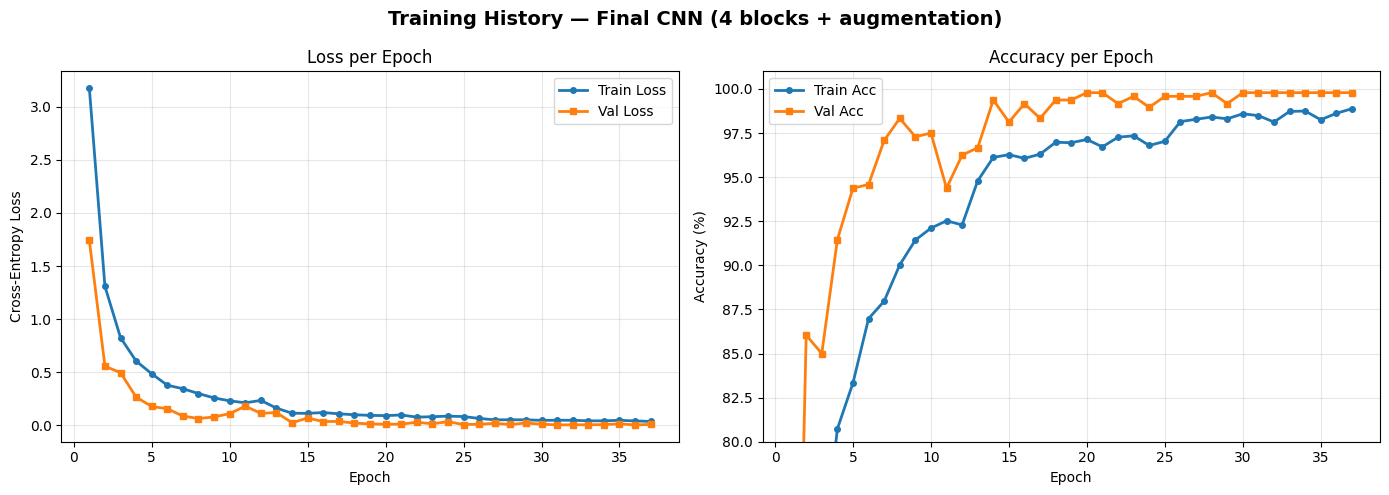

Saved: final_training_curves.png


In [19]:
epochs_trained = len(history['train_loss'])
epochs_range   = range(1, epochs_trained + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History — Final CNN (4 blocks + augmentation)', fontsize=14, fontweight='bold')

# Loss plot
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', markersize=4, linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='s', markersize=4, linewidth=2)
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot (scaled to %)
axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train Acc', marker='o', markersize=4, linewidth=2)
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Val Acc',   marker='s', markersize=4, linewidth=2)
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim([80, 101])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_training_curves.png')

## 10. Test Set Evaluation

The test set was never touched during training or hyperparameter decisions — it is the true held-out measure of generalization. We report:
- **Accuracy** — overall percentage correct
- **F1 Score (macro)** — average F1 per class, treating all classes equally. This matters for multi-class problems even when the dataset is balanced, because it shows whether the model is consistent across all gesture types.
- **Confusion matrix** — reveals *which* classes get confused with each other, giving more actionable insight than a single accuracy number.

Loaded best model from "best_final_model.pth"

Test Accuracy : 0.9979  (99.79%)
F1 Score (macro): 0.9979

Per-class classification report:
              precision    recall  f1-score   support

   back_hand       1.00      0.97      0.98        30
           c       1.00      1.00      1.00        30
       cross       1.00      1.00      1.00        30
        down       1.00      1.00      1.00        30
        fist       1.00      1.00      1.00        30
        four       1.00      1.00      1.00        30
  hand-heart       1.00      1.00      1.00        30
       index       1.00      1.00      1.00        30
           l       1.00      1.00      1.00        30
          ok       0.97      1.00      0.98        30
        palm       1.00      1.00      1.00        30
       peace       1.00      1.00      1.00        30
        rock       1.00      1.00      1.00        30
       three       1.00      1.00      1.00        30
       thumb       1.00      1.00      1.00       

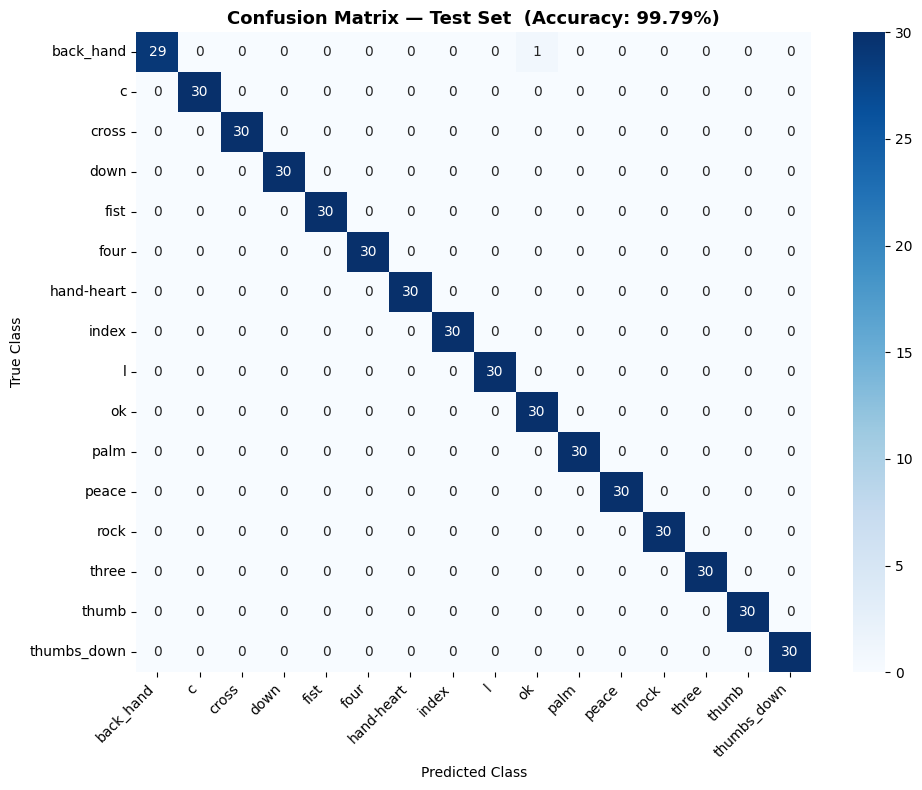

Saved: final_confusion_matrix.png


In [20]:
# Load the best checkpoint (in case this cell is run after kernel restart)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.eval()
print(f'Loaded best model from "{BEST_MODEL_PATH}"')

all_preds  = []
all_truths = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs    = imgs.to(device)
        outputs = model(imgs)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_truths.extend(lbls.numpy())

all_preds  = np.array(all_preds)
all_truths = np.array(all_truths)

test_acc = (all_preds == all_truths).mean()
test_f1  = f1_score(all_truths, all_preds, average='macro')

print(f'\nTest Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'F1 Score (macro): {test_f1:.4f}')
print()
print('Per-class classification report:')
print(classification_report(all_truths, all_preds, target_names=CLASS_NAMES))

# Confusion matrix — rows = true class, columns = predicted class
cm = confusion_matrix(all_truths, all_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
)
ax.set_title(f'Confusion Matrix — Test Set  (Accuracy: {test_acc*100:.2f}%)', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: final_confusion_matrix.png')

## 11. GradCAM Visualization

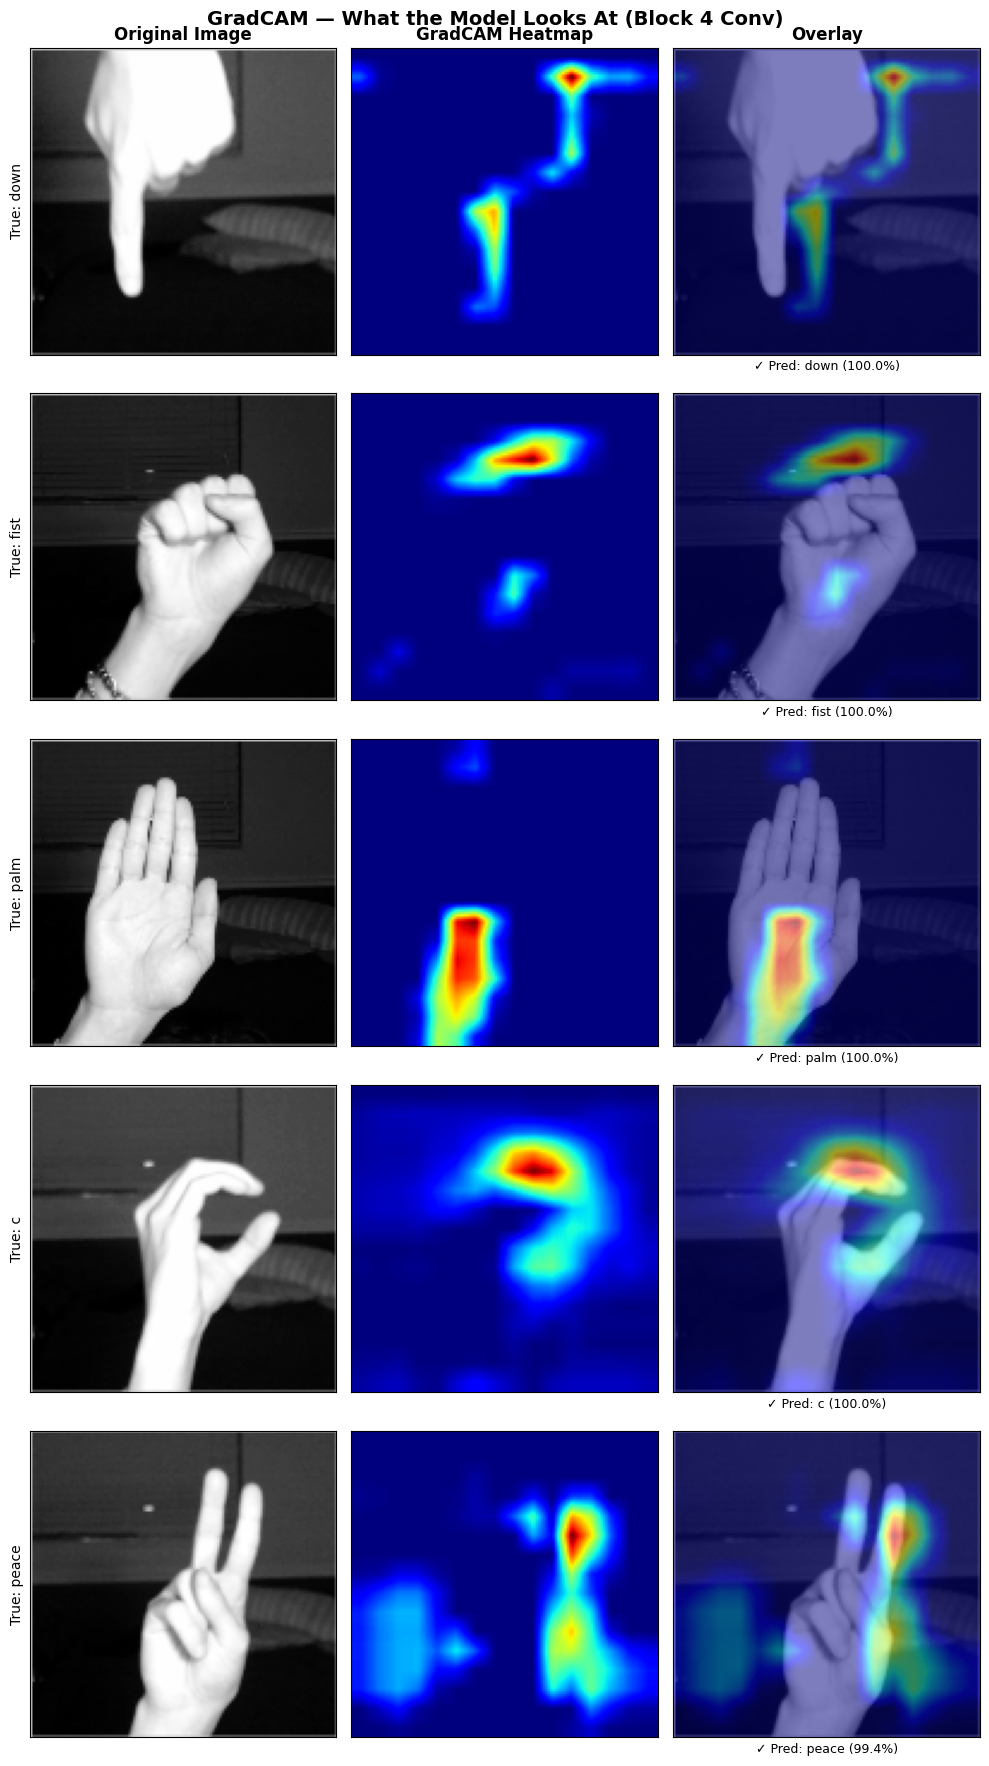

Saved: gradcam_samples.png


In [15]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.activations = None
        self.gradients   = None

        # register_forward_hook captures the layer's output (activations) on every forward pass
        self._fwd_hook = target_layer.register_forward_hook(self._save_activations)
        # register_full_backward_hook captures the gradient of the loss w.r.t. those activations
        self._bwd_hook = target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, input, output):
        self.activations = output.detach()

    def _save_gradients(self, module, grad_input, grad_output):
        # grad_output[0] has shape [batch, channels, H, W]
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        """
        Returns (cam_np, class_idx, confidence) where cam_np is a [H_cam, W_cam] array in [0,1].
        If class_idx is None, uses the predicted class.
        """
        self.model.eval()
        # requires_grad_(True) so gradients flow back through the network to our hook
        input_tensor = input_tensor.requires_grad_(True)

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        # Differentiate the class score w.r.t. all parameters — this propagates
        # back through the network and triggers our backward hook
        output[0, class_idx].backward()

        # Global average pool: average each channel's gradients over the spatial dims
        # Result shape: [1, C] — one weight per filter channel
        weights = self.gradients.mean(dim=[2, 3])  # [1, C]

        # Weighted sum of activation maps — channels with high positive gradients
        # contribute most to the class score and therefore the heatmap
        # Vectorised: broadcast weights over H,W then sum channels
        cam = (weights[0, :, None, None] * self.activations[0]).sum(dim=0)

        # ReLU: keep only positive contributions (negative = suppresses this class)
        cam = torch.relu(cam)

        # Normalize to [0, 1] for visualization
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()

        confidence = output.softmax(dim=1)[0, class_idx].item()
        return cam.cpu().numpy(), class_idx, confidence

    def remove_hooks(self):
        """Always remove hooks after use to avoid memory leaks."""
        self._fwd_hook.remove()
        self._bwd_hook.remove()


# Attach GradCAM to the Conv2d layer inside block4 (index 0 in the Sequential)
gradcam = GradCAM(model, target_layer=model.block4[0])

# Collect 5 samples from the test set spanning different classes
sample_imgs_cam  = []
sample_lbls_cam  = []
seen_classes     = set()

for img, lbl in test_dataset:
    lbl_int = lbl.item()
    if lbl_int not in seen_classes:
        sample_imgs_cam.append(img)
        sample_lbls_cam.append(lbl_int)
        seen_classes.add(lbl_int)
    if len(sample_imgs_cam) == 5:
        break

fig, axes = plt.subplots(5, 3, figsize=(10, 18))
fig.suptitle('GradCAM — What the Model Looks At (Block 4 Conv)', fontsize=14, fontweight='bold')

col_titles = ['Original Image', 'GradCAM Heatmap', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold')

for row, (img_tensor, true_lbl) in enumerate(zip(sample_imgs_cam, sample_lbls_cam)):
    input_batch = img_tensor.unsqueeze(0).to(device)  # add batch dimension

    cam_np, pred_idx, confidence = gradcam.generate(input_batch)

    # Upsample CAM from 8×8 to 128×128 for overlay
    cam_pil     = Image.fromarray((cam_np * 255).astype(np.uint8)).resize((128, 128), Image.BILINEAR)
    cam_resized = np.array(cam_pil) / 255.0

    orig_np  = img_tensor.squeeze().cpu().numpy()   # [128, 128] in [0, 1]
    orig_rgb = np.stack([orig_np] * 3, axis=2)      # convert grayscale to fake-RGB for blending

    # Apply 'jet' colormap to the heatmap
    heatmap = mpl_cm.jet(cam_resized)[:, :, :3]     # drop alpha channel → [H, W, 3]

    # Alpha-blend: 50% original + 50% heatmap
    overlay = np.clip(0.5 * orig_rgb + 0.5 * heatmap, 0, 1)

    true_name = CLASS_NAMES[true_lbl]
    pred_name = CLASS_NAMES[pred_idx]
    correct   = '✓' if pred_idx == true_lbl else '✗'

    axes[row, 0].imshow(orig_np, cmap='gray')
    axes[row, 0].set_ylabel(f'True: {true_name}', fontsize=10)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    axes[row, 1].imshow(cam_resized, cmap='jet')
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_xlabel(f'{correct} Pred: {pred_name} ({confidence:.1%})', fontsize=9)
    axes[row, 2].set_xticks([])
    axes[row, 2].set_yticks([])

gradcam.remove_hooks()

plt.tight_layout()
plt.savefig('gradcam_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: gradcam_samples.png')

## 12. Live Webcam Demo *(Optional / Interactive)*

> **Run this cell only in a local Jupyter environment with a webcam attached.** It will not work in Colab

This demo captures frames from your webcam and runs real-time inference using the trained model. A green box is drawn in the center of the frame — hold your hand inside it to get a prediction.

**Note:** The model was trained on Leap Motion *infrared* images (bright hand, dark background). Regular webcam images look very different, so you may see lower confidence scores. Holding your hand against a plain dark background under good lighting will give the best results. This gap between training and real-world conditions is called **domain shift** — a common challenge in deployed vision models. I was able to improve confidence levels after compiling my own dataset and retraining the model on it.

**Press `Q` to quit the webcam window.**

Install dependency if needed:
```bash
pip install opencv-python
```

In [2]:
# ── Quick-load cell — run this instead of the full notebook if the model is already trained ──
# Requires: best_final_model.pth exists in the same folder as this notebook

# Must match what you set in cell 2 when you trained the model
USE_CUSTOM_DATASET = True   # True = my_gesture_data,  False = leapgestrecog

import os, torch, torch.nn as nn
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Rebuild CLASS_NAMES from whichever dataset was used for training
if USE_CUSTOM_DATASET:
    DATA_DIR = Path('./my_gesture_data')
    raw_labels = [d.name for d in sorted(DATA_DIR.iterdir()) if d.is_dir()]
    CLASS_NAMES = sorted(raw_labels)
else:
    DATA_DIR = Path('./leapgestrecog/leapGestRecog')
    raw_labels = []
    for subject_dir in sorted(DATA_DIR.iterdir()):
        if not subject_dir.is_dir(): continue
        for gesture_dir in sorted(subject_dir.iterdir()):
            if not gesture_dir.is_dir(): continue
            label = '_'.join(gesture_dir.name.split('_')[1:])
            for _ in gesture_dir.glob('*.png'):
                raw_labels.append(label)
    le = LabelEncoder()
    le.fit(raw_labels)
    CLASS_NAMES = list(le.classes_)

NUM_CLASSES = len(CLASS_NAMES)

# Rebuild the model architecture (must match what was trained)
class GestureCNNFinal(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()
        self.block1 = nn.Sequential(nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.block2 = nn.Sequential(nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.block3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.block4 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2))
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(256*8*8, 512), nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(512, num_classes))
    def forward(self, x):
        return self.classifier(self.block4(self.block3(self.block2(self.block1(x)))))

BEST_MODEL_PATH = 'best_final_model.pth'
model = GestureCNNFinal(num_classes=NUM_CLASSES).to(device)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

print(f'Model loaded from {BEST_MODEL_PATH}')
print(f'Classes ({NUM_CLASSES}): {CLASS_NAMES}')
print(f'Device: {device}')

c:\Users\Chris\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:371: UserWarning: Found GPU1 NVIDIA GeForce GTX 1080 which is of compute capability (CC) 6.1.
The following list shows the CCs this version of PyTorch was built for and the hardware CCs it supports:
- 7.5 which supports hardware CC >=7.5,<8.0
- 8.0 which supports hardware CC >=8.0,<9.0 except {8.7}
- 8.6 which supports hardware CC >=8.6,<9.0 except {8.7}
- 9.0 which supports hardware CC >=9.0,<10.0
- 10.0 which supports hardware CC >=10.0,<11.0 except {10.1}
- 12.0 which supports hardware CC >=12.0,<13.0
Please follow the instructions at https://pytorch.org/get-started/locally/ to install a PyTorch release that supports one of these CUDA versions: 12.6
  _warn_unsupported_code(d, device_cc, code_ccs)
c:\Users\Chris\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\cuda\__init__.py:489: UserWarning: 
NVIDIA GeForce GTX 1080 with CUDA capability sm_61 is not compatible with the c

Model loaded from best_final_model.pth
Classes (16): ['back_hand', 'c', 'cross', 'down', 'fist', 'four', 'hand-heart', 'index', 'l', 'ok', 'palm', 'peace', 'rock', 'three', 'thumb', 'thumbs_down']
Device: cuda


In [18]:
# ─── LIVE WEBCAM DEMO — press Q to quit ──────────────────────────────────────────────
# Requires: pip install opencv-python

try:
    import cv2
except ImportError:
    raise ImportError('Install OpenCV with: pip install opencv-python')

# Ensure we use the best trained model
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device, weights_only=True))
model.eval()

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError('Could not open webcam. Check that a camera is connected.')

print('Webcam demo running — press Q in the OpenCV window to quit.')
print('Hold your hand in the green box for best results.')

while True:
    ret, frame = cap.read()
    if not ret:
        print('Failed to grab frame — exiting.')
        break

    h, w = frame.shape[:2]

    # Use a fixed center crop as the region of interest.
    # Make the box 60% of the shorter dimension so it stays square.
    box_size = int(min(h, w) * 0.6)
    x1 = (w - box_size) // 2
    y1 = (h - box_size) // 2
    x2 = x1 + box_size
    y2 = y1 + box_size

    crop = frame[y1:y2, x1:x2]

    # Preprocess to match training input: grayscale → 128×128 → [0,1] tensor
    gray    = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (128, 128))
    tensor  = torch.tensor(resized, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0
    tensor  = tensor.to(device)

    CONFIDENCE_THRESHOLD = 0.60  # below this = no reliable hand detected

    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0]  # shape [num_classes]

    top3_conf, top3_idx = probs.topk(3)
    top_conf  = top3_conf[0].item()
    top_label = CLASS_NAMES[top3_idx[0].item()] if top_conf >= CONFIDENCE_THRESHOLD else None

    # Draw the crop box
    box_color = (0, 255, 0) if top_label else (0, 100, 255)
    cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, 2)

    if top_label:
        # Top-1 prediction
        cv2.putText(frame, f'{top_label}  {top_conf:.1%}', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2, cv2.LINE_AA)
        # Top-2 and top-3 as smaller secondary labels
        for rank, (idx, conf) in enumerate(zip(top3_idx[1:], top3_conf[1:]), start=2):
            text = f'  {rank}. {CLASS_NAMES[idx.item()]}  {conf.item():.1%}'
            cv2.putText(frame, text, (x1, y1 - 10 - rank * 22),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, (180, 255, 180), 1, cv2.LINE_AA)
    else:
        cv2.putText(frame, 'No hand detected', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 100, 255), 2, cv2.LINE_AA)

    cv2.putText(frame, 'Place hand in box  |  Q to quit', (x1, y2 + 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (200, 200, 200), 1, cv2.LINE_AA)

    cv2.imshow('Hand Gesture Recognition — Press Q to quit', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        print('Q pressed — closing webcam.')
        break

cap.release()
cv2.destroyAllWindows()
print('Webcam demo ended.')

Webcam demo running — press Q in the OpenCV window to quit.
Hold your hand in the green box for best results.
Q pressed — closing webcam.
Webcam demo ended.
